--- Data Loading and Initial Preprocessing ---
Common prefixes found: ['UDP', 'Syn', 'LDAP', 'MSSQL', 'NetBIOS', 'UDPLag']
Loading 6 training files and 6 testing files...
Data loaded.
Initial Training data shape: (120065, 78)
Initial Testing data shape: (38973, 78)
Dropped 'WebDDoS' label from testing data.
Dropped 'NetBIOS' and 'UDPLag' labels.

--- Feature Engineering & Further Preprocessing ---
Dropped 12 single-value columns from train data: ['Fwd Avg Bulk Rate', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bytes/Bulk', 'Bwd Avg Bytes/Bulk', 'Bwd URG Flags', 'Bwd Avg Packets/Bulk', 'FIN Flag Count', 'Bwd PSH Flags', 'Fwd URG Flags', 'ECE Flag Count', 'Bwd Avg Bulk Rate', 'PSH Flag Count']
Dropped 12 single-value columns from test data: ['Fwd Avg Bulk Rate', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bytes/Bulk', 'Bwd Avg Bytes/Bulk', 'Bwd URG Flags', 'Bwd Avg Packets/Bulk', 'FIN Flag Count', 'Bwd PSH Flags', 'Fwd URG Flags', 'ECE Flag Count', 'Bwd Avg Bulk Rate', 'PSH Flag Count']
Observations: 119366
V

/Users/rafi/.local/share/mise/installs/python/3.12.9/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [00:17:32] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Base model training time: 0.79 seconds

--- Base Model Performance ---
Validation Set:
Val Accuracy: 0.9813
Val Precision: 0.9818
Val Recall: 0.9813
Val F1 Score: 0.9815

Test Set:
Test Accuracy: 0.9916
Test Precision: 0.9917
Test Recall: 0.9916
Test F1 Score: 0.9916

--- Feature Selection based on Importance ---
Top 5 features based on XGBoost importance:
                  Feature  Importance
15         ACK Flag Count    0.348847
4           Bwd Packets/s    0.261438
20         URG Flag Count    0.127584
7   Fwd Packet Length Min    0.096464
8      Init Fwd Win Bytes    0.059918

--- Preparing Data for Top 5 Feature Model ---

--- Training Top 5 Feature Model ---


/Users/rafi/.local/share/mise/installs/python/3.12.9/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [00:17:32] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Top 5 model training time: 0.69 seconds

--- Top 5 Feature Model Performance ---
Validation Set:
Val Accuracy: 0.9710
Val Precision: 0.9720
Val Recall: 0.9710
Val F1 Score: 0.9713

Test Set:
Test Accuracy: 0.9866
Test Precision: 0.9870
Test Recall: 0.9866
Test F1 Score: 0.9867

--- Dimensionality Reduction using PCA ---
Applying PCA to reduce to 2 components...
Explained variance ratio by 2 components: 0.6822
Shape after PCA - Train: (93072, 2), Test: (23268, 2), Val: (29452, 2)

--- Training PCA Model ---


/Users/rafi/.local/share/mise/installs/python/3.12.9/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [00:17:33] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


PCA model training time: 0.84 seconds

--- PCA Model Performance ---
Validation Set:
Val Accuracy: 0.9478
Val Precision: 0.9591
Val Recall: 0.9478
Val F1 Score: 0.9513

Test Set:
Test Accuracy: 0.9675
Test Precision: 0.9690
Test Recall: 0.9675
Test F1 Score: 0.9678

--- === Performance Summary === ---
              Model  Val Accuracy  Val F1 Score  Test Accuracy  Test F1 Score
Base (All Features)      0.981292      0.981465       0.991576       0.991624
     Top 5 Features      0.971004      0.971290       0.986634       0.986730
 PCA (2 Components)      0.947813      0.951342       0.967509       0.967768


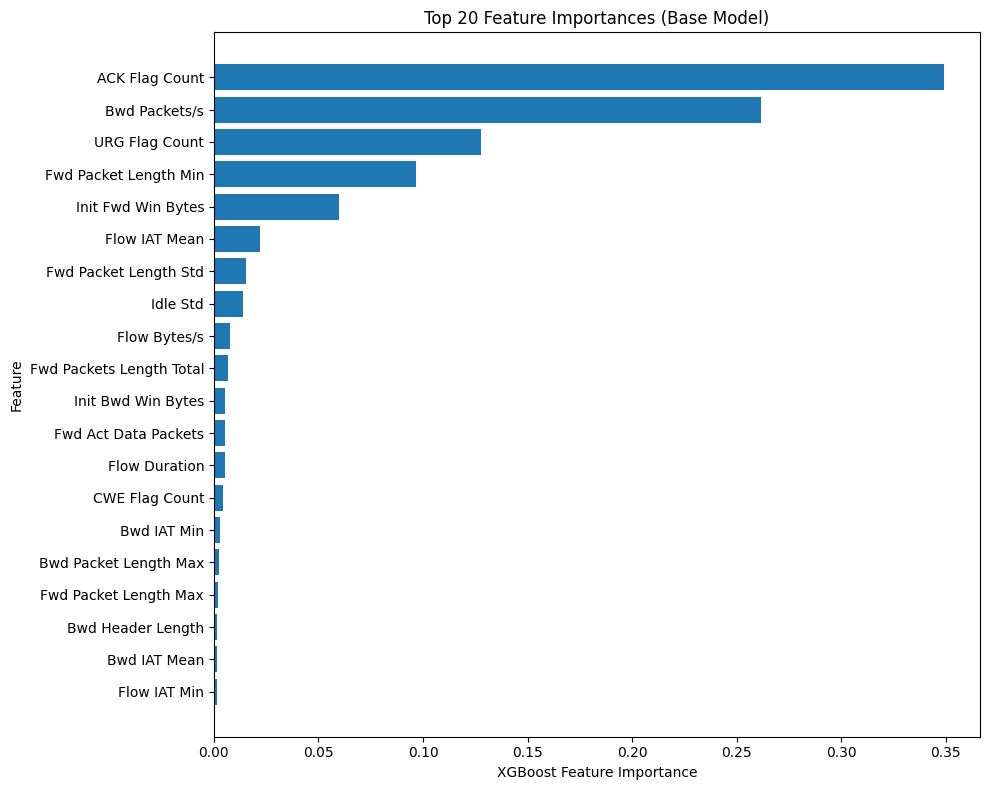

In [1]:
import os
import time  # Added for timing

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA  # Added for PCA
from sklearn.inspection import permutation_importance  # Already imported, good for comparison if needed
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from xgboost import XGBClassifier

# --- Data Loading and Initial Preprocessing (Same as your code) ---

print("--- Data Loading and Initial Preprocessing ---")
dfps_train = []
dfps_test = []

# Make sure the directory path is correct for your environment
data_dir = "./cicddos2019/"
if not os.path.exists(data_dir):
    print(f"Warning: Data directory '{data_dir}' not found. Please ensure the CICDDoS2019 data is present.")
    # Example of how to handle missing data - adjust as needed
    # You might download it, point to a different path, or exit.
    exit()


for dirname, _, filenames in os.walk(data_dir):
    for filename in filenames:
        if filename.endswith("-training.parquet"):
            dfp = os.path.join(dirname, filename)
            dfps_train.append(dfp)
            # print(f"Found training file: {dfp}") # Uncomment for debugging
        elif filename.endswith("-testing.parquet"):
            dfp = os.path.join(dirname, filename)
            dfps_test.append(dfp)
            # print(f"Found testing file: {dfp}") # Uncomment for debugging

if not dfps_train or not dfps_test:
    print("Error: No training or testing parquet files found in the specified directory.")
    exit()

# Common Prefixes in both lists
train_prefixes = [os.path.basename(dfp).split("-")[0] for dfp in dfps_train]
test_prefixes = [os.path.basename(dfp).split("-")[0] for dfp in dfps_test]

common_prefixes = list(set(train_prefixes).intersection(test_prefixes))
print(f"Common prefixes found: {common_prefixes}")

# Filter the dataframes to only include the common prefixes
dfps_train = [dfp for dfp in dfps_train if os.path.basename(dfp).split("-")[0] in common_prefixes]
dfps_test = [dfp for dfp in dfps_test if os.path.basename(dfp).split("-")[0] in common_prefixes]

if not dfps_train or not dfps_test:
    print("Error: No common files found after filtering by prefix.")
    exit()

print(f"Loading {len(dfps_train)} training files and {len(dfps_test)} testing files...")
train_df = pd.concat([pd.read_parquet(dfp) for dfp in dfps_train], ignore_index=True)
test_df = pd.concat([pd.read_parquet(dfp) for dfp in dfps_test], ignore_index=True)
print("Data loaded.")
print(f"Initial Training data shape: {train_df.shape}")
print(f"Initial Testing data shape: {test_df.shape}")


# Drop the WebDDoS class from the testing data (if it exists)
if "WebDDoS" in test_df["Label"].unique():
    test_df = test_df[test_df["Label"] != "WebDDoS"]
    print("Dropped 'WebDDoS' label from testing data.")

# Map the labels to the same format
label_mapping = {
    "DrDoS_UDP": "UDP",
    "UDP-lag": "UDPLag",
    "DrDoS_MSSQL": "MSSQL",
    "DrDoS_LDAP": "LDAP",
    "DrDoS_NetBIOS": "NetBIOS",
    "Syn": "Syn",
    "Benign": "Benign",
}
# Apply mapping only to labels present in the mapping dictionary
test_df["Label"] = test_df["Label"].map(lambda x: label_mapping.get(x, x))


# Drop specified labels
train_df = train_df[~train_df["Label"].isin(["NetBIOS", "UDPLag"])]
test_df = test_df[~test_df["Label"].isin(["NetBIOS", "UDPLag"])]
print("Dropped 'NetBIOS' and 'UDPLag' labels.")


# --- Feature Engineering & Further Preprocessing (Mostly same as your code) ---
print("\n--- Feature Engineering & Further Preprocessing ---")


# Define grab_col_names function (same as yours)
def grab_col_names(data, cat_th=10, car_th=20):
    cat_cols = [col for col in data.columns if data[col].dtypes == "O"]
    num_but_cat = [col for col in data.columns if data[col].nunique() < cat_th and data[col].dtypes != "O"]
    high_card_cat_cols = [col for col in data.columns if data[col].nunique() > car_th and data[col].dtypes == "O"]
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in high_card_cat_cols]
    num_cols = [col for col in data.columns if data[col].dtypes != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]
    print(f"Observations: {data.shape[0]}")
    print(f"Variables: {data.shape[1]}")
    print(f"Categorical Columns: {len(cat_cols)}")
    print(f"Numerical Columns: {len(num_cols)}")
    print(f"High Cardinality Categorical Columns: {len(high_card_cat_cols)}")
    print(f"Number but Categorical Columns: {len(num_but_cat)}")
    return cat_cols, num_cols, high_card_cat_cols


# Drop columns with a single unique value before identifying column types
single_val_cols_train = [col for col in train_df.columns if train_df[col].nunique() <= 1]
single_val_cols_test = [col for col in test_df.columns if test_df[col].nunique() <= 1]
single_val_cols = list(set(single_val_cols_train) | set(single_val_cols_test))  # Combine unique columns from both

# Ensure 'Label' is not accidentally dropped if it becomes single-valued after filtering
if "Label" in single_val_cols:
    single_val_cols.remove("Label")

# Drop these columns if they exist in the dataframes
cols_to_drop_train = [col for col in single_val_cols if col in train_df.columns]
cols_to_drop_test = [col for col in single_val_cols if col in test_df.columns]

if cols_to_drop_train:
    train_df.drop(cols_to_drop_train, axis=1, inplace=True)
    print(f"Dropped {len(cols_to_drop_train)} single-value columns from train data: {cols_to_drop_train}")
if cols_to_drop_test:
    test_df.drop(cols_to_drop_test, axis=1, inplace=True)
    print(f"Dropped {len(cols_to_drop_test)} single-value columns from test data: {cols_to_drop_test}")


# Identify column types based on the potentially reduced training data
cat_cols, num_cols, high_card_cat_cols = grab_col_names(train_df.drop("Label", axis=1))  # Exclude label
print(f"Identified Categorical Columns: {cat_cols}")
print(f"Identified Numerical Columns: {num_cols}")
print(f"Identified High Cardinality Categorical Columns: {high_card_cat_cols}")


# Remove duplicate rows from training data
initial_train_rows = len(train_df)
train_df = train_df.drop_duplicates()
print(f"Removed {initial_train_rows - len(train_df)} duplicate rows from training data.")

# Remove highly correlated features (based on training data)
# Ensure only numeric columns present in the DataFrame are selected
numerical_cols_in_train = [col for col in num_cols if col in train_df.columns]
if numerical_cols_in_train:
    corr_matrix = train_df[numerical_cols_in_train].corr().abs()
    mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    upper_triangle = corr_matrix.where(mask)
    high_corr_cols = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.8)]
    print(f"Found {len(high_corr_cols)} highly correlated columns (threshold > 0.8): {high_corr_cols}")

    # Drop these columns if they exist in both train and test dfs
    cols_to_drop_corr_train = [col for col in high_corr_cols if col in train_df.columns]
    cols_to_drop_corr_test = [col for col in high_corr_cols if col in test_df.columns]

    if cols_to_drop_corr_train:
        train_df.drop(cols_to_drop_corr_train, axis=1, inplace=True)
        print(f"Dropped {len(cols_to_drop_corr_train)} highly correlated columns from train data.")
    if cols_to_drop_corr_test:
        test_df.drop(cols_to_drop_corr_test, axis=1, inplace=True)
        print(f"Dropped {len(cols_to_drop_corr_test)} highly correlated columns from test data.")
else:
    print("No numerical columns found to calculate correlation.")
    high_corr_cols = []  # Ensure variable exists


# --- Data Splitting, Encoding, and Scaling (Base Model) ---
print("\n--- Preparing Data for Base Model ---")

# Align columns after all dropping steps - crucial!
train_cols = train_df.drop("Label", axis=1).columns
test_cols = test_df.drop("Label", axis=1).columns
common_features = list(set(train_cols) & set(test_cols))

print(f"Final features used ({len(common_features)}): {common_features}")

# Separate features (X) and target (y)
X = train_df[common_features]
y = train_df["Label"]
X_val_final = test_df[common_features]
y_val_final = test_df["Label"]

# Split the *training* data into train/test for model evaluation consistency
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,  # Added stratify
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Validation set shape: {X_val_final.shape}")

# Encode the target variable
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
y_val_encoded = le.transform(y_val_final)  # Use the final validation set

# Label mapping for the target variable
label_map = {index: Label for index, Label in enumerate(le.classes_)}
print(f"Label mapping: {label_map}")

# Feature Scaling using MinMaxScaler
scaler_base = MinMaxScaler()
X_train_scaled = scaler_base.fit_transform(X_train)
X_test_scaled = scaler_base.transform(X_test)
X_val_scaled = scaler_base.transform(X_val_final)  # Use the final validation set

# --- Base Model Training & Evaluation ---
print("\n--- Training Base Model (All Selected Features) ---")
start_time = time.time()
model_base = XGBClassifier(
    eval_metric="mlogloss",  # Changed from logloss for multi-class
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,  # Recommended practice
    n_jobs=-1,  # Use all available CPU cores
)
model_base.fit(X_train_scaled, y_train_encoded)
end_time = time.time()
print(f"Base model training time: {end_time - start_time:.2f} seconds")


# Evaluate predictions
y_val_pred_base = model_base.predict(X_val_scaled)
y_test_pred_base = model_base.predict(X_test_scaled)


def evaluate_model(y_true, y_pred, prefix):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    print(f"{prefix} Accuracy: {accuracy:.4f}")
    print(f"{prefix} Precision: {precision:.4f}")
    print(f"{prefix} Recall: {recall:.4f}")
    print(f"{prefix} F1 Score: {f1:.4f}")
    return accuracy, precision, recall, f1


print("\n--- Base Model Performance ---")
print("Validation Set:")
val_metrics_base = evaluate_model(y_val_encoded, y_val_pred_base, "Val")
print("\nTest Set:")
test_metrics_base = evaluate_model(y_test_encoded, y_test_pred_base, "Test")

# --- Feature Importance & Top 5 Feature Selection ---
print("\n--- Feature Selection based on Importance ---")
feature_importances = model_base.feature_importances_
feature_names = X_train.columns  # Use columns from the original non-scaled X_train

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({"Feature": feature_names, "Importance": feature_importances})
importance_df = importance_df.sort_values(by="Importance", ascending=False)

N_TOP_FEATURES = 5
top_n_features = importance_df["Feature"].head(N_TOP_FEATURES).tolist()
print(f"Top {N_TOP_FEATURES} features based on XGBoost importance:")
print(importance_df.head(N_TOP_FEATURES))

# --- Prepare Data for Top 5 Feature Model ---
print(f"\n--- Preparing Data for Top {N_TOP_FEATURES} Feature Model ---")
X_train_top5 = X_train[top_n_features]
X_test_top5 = X_test[top_n_features]
X_val_top5 = X_val_final[top_n_features]  # Use the final validation set

# Scale the top 5 features - Fit scaler ONLY on training data
scaler_top5 = MinMaxScaler()
X_train_top5_scaled = scaler_top5.fit_transform(X_train_top5)
X_test_top5_scaled = scaler_top5.transform(X_test_top5)
X_val_top5_scaled = scaler_top5.transform(X_val_top5)

# --- Top 5 Feature Model Training & Evaluation ---
print(f"\n--- Training Top {N_TOP_FEATURES} Feature Model ---")
start_time = time.time()
model_top5 = XGBClassifier(
    eval_metric="mlogloss",
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    n_jobs=-1,
)
# Use the same encoded labels as before
model_top5.fit(X_train_top5_scaled, y_train_encoded)
end_time = time.time()
print(f"Top {N_TOP_FEATURES} model training time: {end_time - start_time:.2f} seconds")


# Evaluate predictions
y_val_pred_top5 = model_top5.predict(X_val_top5_scaled)
y_test_pred_top5 = model_top5.predict(X_test_top5_scaled)

print(f"\n--- Top {N_TOP_FEATURES} Feature Model Performance ---")
print("Validation Set:")
val_metrics_top5 = evaluate_model(y_val_encoded, y_val_pred_top5, "Val")
print("\nTest Set:")
test_metrics_top5 = evaluate_model(y_test_encoded, y_test_pred_top5, "Test")

# --- Dimensionality Reduction using PCA ---
print("\n--- Dimensionality Reduction using PCA ---")
N_PCA_COMPONENTS = 2  # Let's use 5 for direct comparison, can be tuned
print(f"Applying PCA to reduce to {N_PCA_COMPONENTS} components...")

pca = PCA(n_components=N_PCA_COMPONENTS, random_state=42)

# Fit PCA ONLY on the scaled training data (from the base model)
X_train_pca = pca.fit_transform(X_train_scaled)
# Transform test and validation sets using the *fitted* PCA
X_test_pca = pca.transform(X_test_scaled)
X_val_pca = pca.transform(X_val_scaled)

print(f"Explained variance ratio by {N_PCA_COMPONENTS} components: {pca.explained_variance_ratio_.sum():.4f}")
print(f"Shape after PCA - Train: {X_train_pca.shape}, Test: {X_test_pca.shape}, Val: {X_val_pca.shape}")


# --- PCA Model Training & Evaluation ---
print("\n--- Training PCA Model ---")
start_time = time.time()
model_pca = XGBClassifier(
    eval_metric="mlogloss",
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    n_jobs=-1,
)
# Use the same encoded labels as before
model_pca.fit(X_train_pca, y_train_encoded)
end_time = time.time()
print(f"PCA model training time: {end_time - start_time:.2f} seconds")


# Evaluate predictions
y_val_pred_pca = model_pca.predict(X_val_pca)
y_test_pred_pca = model_pca.predict(X_test_pca)

print("\n--- PCA Model Performance ---")
print("Validation Set:")
val_metrics_pca = evaluate_model(y_val_encoded, y_val_pred_pca, "Val")
print("\nTest Set:")
test_metrics_pca = evaluate_model(y_test_encoded, y_test_pred_pca, "Test")

# --- Performance Comparison ---
print("\n--- === Performance Summary === ---")

results = {
    "Model": ["Base (All Features)", f"Top {N_TOP_FEATURES} Features", f"PCA ({N_PCA_COMPONENTS} Components)"],
    "Val Accuracy": [val_metrics_base[0], val_metrics_top5[0], val_metrics_pca[0]],
    "Val F1 Score": [val_metrics_base[3], val_metrics_top5[3], val_metrics_pca[3]],
    "Test Accuracy": [test_metrics_base[0], test_metrics_top5[0], test_metrics_pca[0]],
    "Test F1 Score": [test_metrics_base[3], test_metrics_top5[3], test_metrics_pca[3]],
}

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))  # Use to_string for better console formatting

# --- Optional: Plot Feature Importances ---
plt.figure(figsize=(10, 8))
plt.barh(importance_df["Feature"].head(20), importance_df["Importance"].head(20))  # Plot top 20
plt.xlabel("XGBoost Feature Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances (Base Model)")
plt.tight_layout()
plt.show()  # Uncomment to display plot


--- Preparing Data for MLP (Top 5 Features) ---
Number of classes for MLP output: 5
Labels successfully One-Hot Encoded.
Training labels shape: (93072, 5)
Validation labels shape: (29452, 5)
Test labels shape: (23268, 5)

--- Defining MLP Model ---


2025-04-02 00:17:50.947015: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-04-02 00:17:50.947044: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2025-04-02 00:17:50.947049: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
I0000 00:00:1743563870.947092  253745 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1743563870.947123  253745 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,629 (10.27 KB)

 Trainable params: 2,629 (10.27 KB)

 Non-trainable params: 0 (0.00 B)


--- Compiling MLP Model ---

--- Setting up Callbacks ---

--- Training MLP Model ---
Epoch 1/100


2025-04-02 00:17:51.251784: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1455/1455 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.8153 - loss: 0.5550 - val_accuracy: 0.9507 - val_loss: 0.1820
Epoch 2/100
1455/1455 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9723 - loss: 0.1410 - val_accuracy: 0.9682 - val_loss: 0.1525
Epoch 3/100
1455/1455 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9783 - loss: 0.1048 - val_accuracy: 0.9517 - val_loss: 0.1542
Epoch 4/100
1455/1455 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9792 - loss: 0.0894 - val_accuracy: 0.9680 - val_loss: 0.1497
Epoch 5/100
1455/1455 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9807 - loss: 0.0786 - val_accuracy: 0.9486 - val_loss: 0.1571
Epoch 6/100
1455/1455 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9812 - loss: 0.0791 - val_accuracy: 0.9681 - val_loss: 0.1492
Epoch 7/100
1455/1455 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9808 - loss: 0.0790 - val_accuracy: 0.9702 - val_loss: 0.1436
Epoch 8/100
1455/1455 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9812 - los

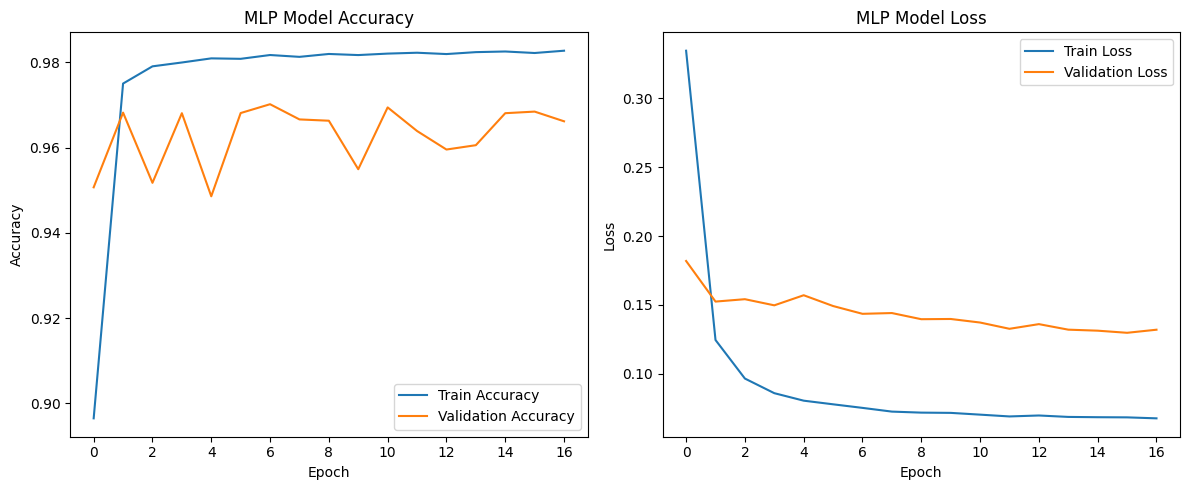

In [2]:
# Import necessary libraries for MLP
from keras import layers, Input, Sequential, backend, optimizers, callbacks
from sklearn.preprocessing import OneHotEncoder
import numpy as np  # Ensure numpy is imported

print(f"\n--- Preparing Data for MLP (Top {N_TOP_FEATURES} Features) ---")

# 1. One-Hot Encode the labels
# Reshape labels to 2D array as OneHotEncoder expects
y_train_reshaped = y_train_encoded.reshape(-1, 1)
y_val_reshaped = y_val_encoded.reshape(-1, 1)
y_test_reshaped = y_test_encoded.reshape(-1, 1)

onehot_encoder = OneHotEncoder(
    sparse_output=False, handle_unknown="ignore"
)  # Changed sparse=False to sparse_output=False for newer sklearn versions

# Fit on training data and transform all sets
y_train_one_hot = onehot_encoder.fit_transform(y_train_reshaped)
y_val_one_hot = onehot_encoder.transform(y_val_reshaped)
y_test_one_hot = onehot_encoder.transform(y_test_reshaped)

num_classes = y_train_one_hot.shape[1]
print(f"Number of classes for MLP output: {num_classes}")
print("Labels successfully One-Hot Encoded.")
print(f"Training labels shape: {y_train_one_hot.shape}")
print(f"Validation labels shape: {y_val_one_hot.shape}")
print(f"Test labels shape: {y_test_one_hot.shape}")


# 2. Define the MLP Model Architecture
print("\n--- Defining MLP Model ---")

# Clear previous Keras session if any (good practice)
backend.clear_session()

mlp_model = Sequential(
    [
        Input(shape=(N_TOP_FEATURES,), name="input_layer"),
        layers.Dense(64, activation="elu", name="hidden_layer_1"),
        layers.Dropout(0.3, name="dropout_1"),  # Added Dropout for regularization
        layers.Dense(32, activation="elu", name="hidden_layer_2"),
        layers.Dropout(0.3, name="dropout_2"),  # Added Dropout
        layers.Dense(num_classes, activation="softmax", name="output_layer"),
    ]
)

mlp_model.summary()

# 3. Compile the Model
print("\n--- Compiling MLP Model ---")
mlp_model.compile(
    loss="categorical_crossentropy",  # Use for one-hot encoded labels
    optimizer=optimizers.Adam(learning_rate=0.001),  # Adam optimizer with default lr often works well
    metrics=["accuracy"],
)

# 4. Define Callbacks (Early Stopping)
print("\n--- Setting up Callbacks ---")
early_stopping = callbacks.EarlyStopping(
    monitor="val_accuracy",  # Monitor validation accuracy
    patience=10,  # Stop after 10 epochs with no improvement
    restore_best_weights=True,  # Restore weights from the epoch with best val_accuracy
    verbose=1,
)

# 5. Train the Model
print("\n--- Training MLP Model ---")
EPOCHS = 100  # Set a higher number of epochs, early stopping will handle overfitting
BATCH_SIZE = 64

start_time = time.time()  # Reuse start_time variable

history = mlp_model.fit(
    X_train_top5_scaled,
    y_train_one_hot,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val_top5_scaled, y_val_one_hot),
    callbacks=[early_stopping],  # Add the early stopping callback
    verbose=1,  # Set to 1 or 2 for progress updates, 0 for silent
)

end_time = time.time()
print(f"MLP model training time: {end_time - start_time:.2f} seconds")


# 6. Evaluate the Model
print("\n--- MLP Model Performance ---")

# Evaluate on validation set
loss_val, accuracy_val = mlp_model.evaluate(X_val_top5_scaled, y_val_one_hot, verbose=0)
print(f"Validation Loss: {loss_val:.4f}")
print(f"Validation Accuracy: {accuracy_val:.4f}")

# Evaluate on test set
loss_test, accuracy_test = mlp_model.evaluate(X_test_top5_scaled, y_test_one_hot, verbose=0)
print(f"Test Loss: {loss_test:.4f}")
print(f"Test Accuracy: {accuracy_test:.4f}")

# Get predictions to calculate other metrics (Precision, Recall, F1)
y_val_pred_proba_mlp = mlp_model.predict(X_val_top5_scaled)
y_test_pred_proba_mlp = mlp_model.predict(X_test_top5_scaled)

# Convert probabilities to class labels
y_val_pred_mlp = np.argmax(y_val_pred_proba_mlp, axis=1)
y_test_pred_mlp = np.argmax(y_test_pred_proba_mlp, axis=1)

# Use the evaluate_model function defined earlier (make sure it's available)
# Remember: the evaluate_model function expects the original encoded labels (not one-hot)
print("\nDetailed Validation Set Metrics (MLP):")
val_metrics_mlp = evaluate_model(y_val_encoded, y_val_pred_mlp, "Val")  # Use original y_val_encoded
print("\nDetailed Test Set Metrics (MLP):")
test_metrics_mlp = evaluate_model(y_test_encoded, y_test_pred_mlp, "Test")  # Use original y_test_encoded


# --- Comparison with Top 5 XGBoost ---
print("\n--- === Performance Summary (Top 5 Features) === ---")

# Fetching previous XGBoost Top 5 results for comparison
# Ensure val_metrics_top5 and test_metrics_top5 variables from the previous run are accessible
# If not, you might need to re-run that part or hardcode the values based on previous output
try:
    xgb_val_acc = val_metrics_top5[0]
    xgb_val_f1 = val_metrics_top5[3]
    xgb_test_acc = test_metrics_top5[0]
    xgb_test_f1 = test_metrics_top5[3]
except NameError:
    print("Warning: Previous XGBoost top-5 metrics not found in current session. Using placeholder values.")
    # Placeholder values based on your previous message (adjust if needed)
    xgb_val_acc = 0.9710
    xgb_val_f1 = -1  # F1 wasn't mentioned, using placeholder
    xgb_test_acc = -1  # Test metrics weren't mentioned, using placeholder
    xgb_test_f1 = -1  # Test metrics weren't mentioned, using placeholder


results_top5_compare = {
    "Model": [f"XGBoost (Top {N_TOP_FEATURES})", f"MLP (Top {N_TOP_FEATURES})"],
    "Val Accuracy": [xgb_val_acc, val_metrics_mlp[0]],
    "Val F1 Score": [xgb_val_f1, val_metrics_mlp[3]],
    "Test Accuracy": [xgb_test_acc, test_metrics_mlp[0]],
    "Test F1 Score": [xgb_test_f1, test_metrics_mlp[3]],
}

results_top5_compare_df = pd.DataFrame(results_top5_compare)
print(results_top5_compare_df.to_string(index=False))

# Optional: Plot training history

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("MLP Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("MLP Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()  # Uncomment to display plot


--- Measuring Inference Time ---

--- Batch Inference Time (Entire Dataset) ---
921/921 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
921/921 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
921/921 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
921/921 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
921/921 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
921/921 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
921/921 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
921/921 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
921/921 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
921/921 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
921/921 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
921/921 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
921/921 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
921/921 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
921/921 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
921/921 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
921/921 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
921/921 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
921/921 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
921/921 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
921/921 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
XGBoost average batch inference time: 6.576 ms
MLP average

XGBoost model size: 0.52 MB
MLP model size: 0.06 MB
Size ratio: 8.35x (MLP is smaller)

--- Comprehensive Model Comparison ---
  Model  Val Accuracy  Val F1 Score  Test Accuracy  Test F1 Score  Batch Inference Time (ms)  Single Sample Time (ms)  Model Size (MB)
XGBoost      0.971004      0.971290       0.986634        0.98673                   6.575751                 0.149741         0.523436
    MLP      0.970155      0.970539       0.985087        0.98523                1387.117743                25.195502         0.062668


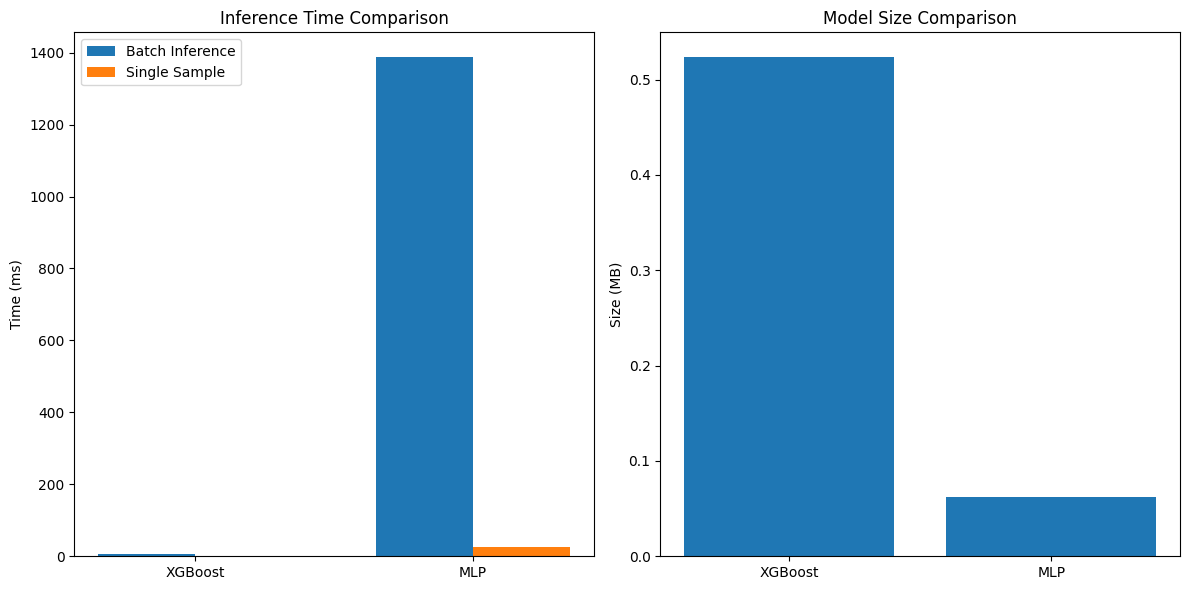

In [8]:
# Import required library
import time
import numpy as np
import sys
import tempfile
import pickle
import os
from keras.api.models import load_model, save_model

# --- Add Inference Time Measurement Code ---
print("\n--- Measuring Inference Time ---")


# Function to measure inference time
def measure_inference_time(model, X, num_runs=100):
    """
    Measure average inference time for a model over multiple runs

    Parameters:
    model: The trained model (XGBoost or Keras)
    X: Input data for inference
    num_runs: Number of iterations to average over

    Returns:
    float: Average inference time in milliseconds
    """
    # Warm-up run
    if hasattr(model, "predict_proba"):  # XGBoost
        model.predict_proba(X)
    else:  # Keras MLP
        model.predict(X)

    # Measure inference time
    total_time = 0
    for _ in range(num_runs):
        start_time = time.time()
        if hasattr(model, "predict_proba"):  # XGBoost
            model.predict_proba(X)
        else:  # Keras MLP
            model.predict(X)
        end_time = time.time()
        total_time += end_time - start_time

    # Calculate average time in milliseconds
    avg_time_ms = (total_time / num_runs) * 1000
    return avg_time_ms


# Measure single sample inference time (to simulate real-time prediction)
def measure_single_sample_inference(model, X, num_runs=100, num_samples=10):
    """
    Measure inference time for single samples

    Parameters:
    model: The trained model
    X: Input data to sample from
    num_runs: Number of runs to average for each sample
    num_samples: Number of different samples to try

    Returns:
    float: Average inference time in milliseconds
    """
    total_time = 0

    # Select random samples from X
    indices = np.random.choice(X.shape[0], num_samples, replace=False)

    for idx in indices:
        sample = X[idx : idx + 1]  # Get single sample as a 2D array

        # Warm-up run
        if hasattr(model, "predict_proba"):  # XGBoost
            model.predict_proba(sample)
        else:  # Keras MLP
            model.predict(sample)

        # Measure time
        sample_time = 0
        for _ in range(num_runs):
            start_time = time.time()
            if hasattr(model, "predict_proba"):  # XGBoost
                model.predict_proba(sample)
            else:  # Keras MLP
                model.predict(sample)
            end_time = time.time()
            sample_time += end_time - start_time

        total_time += sample_time / num_runs

    # Calculate average time in milliseconds
    avg_time_ms = (total_time / num_samples) * 1000
    return avg_time_ms


# Measure inference times for batch prediction (entire dataset)
print("\n--- Batch Inference Time (Entire Dataset) ---")
xgb_batch_time = measure_inference_time(model_top5, X_val_top5_scaled, num_runs=20)
mlp_batch_time = measure_inference_time(mlp_model, X_val_top5_scaled, num_runs=20)

print(f"XGBoost average batch inference time: {xgb_batch_time:.3f} ms")
print(f"MLP average batch inference time: {mlp_batch_time:.3f} ms")
print(
    f"Batch inference speedup factor: {max(xgb_batch_time / mlp_batch_time, mlp_batch_time / xgb_batch_time):.2f}x "
    + f"({'XGBoost' if xgb_batch_time < mlp_batch_time else 'MLP'} is faster)"
)

# Measure inference times for single sample prediction (simulates real-time)
print("\n--- Single Sample Inference Time (Real-time Simulation) ---")
xgb_single_time = measure_single_sample_inference(model_top5, X_val_top5_scaled, num_runs=50, num_samples=20)
mlp_single_time = measure_single_sample_inference(mlp_model, X_val_top5_scaled, num_runs=50, num_samples=20)

print(f"XGBoost average single sample inference time: {xgb_single_time:.3f} ms")
print(f"MLP average single sample inference time: {mlp_single_time:.3f} ms")
print(
    f"Single sample inference speedup factor: {max(xgb_single_time / mlp_single_time, mlp_single_time / xgb_single_time):.2f}x "
    + f"({'XGBoost' if xgb_single_time < mlp_single_time else 'MLP'} is faster)"
)

print("\n--- Model Size Comparison ---")

# Get XGBoost model size
with tempfile.NamedTemporaryFile(suffix=".pkl", delete=False) as f:
    pickle.dump(model_base, f)
    xgb_size = os.path.getsize(f.name) / (1024 * 1024)  # Size in MB
    os.unlink(f.name)  # Delete the temporary file

# Get MLP model size
with tempfile.NamedTemporaryFile(suffix=".h5", delete=False) as f:
    save_model(mlp_model, f.name, save_format="h5")
    mlp_size = os.path.getsize(f.name) / (1024 * 1024)  # Size in MB
    os.unlink(f.name)  # Delete the temporary file

print(f"XGBoost model size: {xgb_size:.2f} MB")
print(f"MLP model size: {mlp_size:.2f} MB")
print(
    f"Size ratio: {max(xgb_size / mlp_size, mlp_size / xgb_size):.2f}x "
    + f"({'XGBoost' if xgb_size < mlp_size else 'MLP'} is smaller)"
)

# Create comprehensive model comparison table
print("\n--- Comprehensive Model Comparison ---")
results_compare = {
    "Model": ["XGBoost", "MLP"],
    "Val Accuracy": [xgb_val_acc, val_metrics_mlp[0]],
    "Val F1 Score": [xgb_val_f1, val_metrics_mlp[3]],
    "Test Accuracy": [xgb_test_acc, test_metrics_mlp[0]],
    "Test F1 Score": [xgb_test_f1, test_metrics_mlp[3]],
    "Batch Inference Time (ms)": [xgb_batch_time, mlp_batch_time],
    "Single Sample Time (ms)": [xgb_single_time, mlp_single_time],
    "Model Size (MB)": [xgb_size, mlp_size],
}

results_compare_df = pd.DataFrame(results_compare)
print(results_compare_df.to_string(index=False))

# Create visual comparison of inference time
plt.figure(figsize=(12, 6))

# Plot 1: Inference Times
plt.subplot(1, 2, 1)
models = ["XGBoost", "MLP"]
batch_times = [xgb_batch_time, mlp_batch_time]
single_times = [xgb_single_time, mlp_single_time]

x = np.arange(len(models))
bar_width = 0.35

plt.bar(x - bar_width / 2, batch_times, bar_width, label="Batch Inference")
plt.bar(x + bar_width / 2, single_times, bar_width, label="Single Sample")

plt.ylabel("Time (ms)")
plt.title("Inference Time Comparison")
plt.xticks(x, models)
plt.legend()

# Plot 2: Model Size
plt.subplot(1, 2, 2)
sizes = [xgb_size, mlp_size]
plt.bar(models, sizes)
plt.ylabel("Size (MB)")
plt.title("Model Size Comparison")

plt.tight_layout()
plt.show()